In [1]:
import sys
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()   # because notebook is inside rfa_python/notebooks
sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import rfa_model.samplers as samplers

importlib.reload(samplers)

from rfa_model.samplers import *

import rfa_model.sampler_diagnostics as sd

importlib.reload(sd)

from rfa_model.sampler_diagnostics import *

import rfa_model as rfa

In [2]:
import rfa_model as rfa

print(rfa.__file__)
print(hasattr(rfa, "interp_yield_model"))

C:\Users\onr5\OneDrive - NIST\dev\pyrfa\rfa_python\rfa_model\__init__.py
True


In [3]:
%matplotlib widget

In [4]:
model_dir = Path("../data/jmonsel")
bronstein_dir = Path("../data/bronstein")

yield_models, energy_models, theta_models = load_default_surface_models(
    model_dir=model_dir,
    bronstein_dir=bronstein_dir,
)

In [5]:
for fam in ["sample", "holder", "receiver", "grid", "collector"]:
    print("\n", fam)

    for yname in ["SEY", "BSEY"]:
        m = yield_models[fam][yname]
        print(
            f"  {yname}: E {m['E'][0]:.3g}–{m['E'][-1]:.3g} eV, "
            f"Y {m['Y'].min():.3g}–{m['Y'].max():.3g}"
        )

    for kind in ["SE", "BSE"]:
        m = energy_models[fam][kind]
        print(f"  energy {kind}: {len(m['tables'])} tables, E {m['E'][0]:.3g}–{m['E'][-1]:.3g}")

    for kind in ["SE", "BSE"]:
        m = theta_models[fam][kind]
        if isinstance(m, str):
            print(f"  theta {kind}: {m}")
        else:
            print(f"  theta {kind}: {len(m['tables'])} tables, E {m['E'][0]:.3g}–{m['E'][-1]:.3g}")


 sample
  SEY: E 75–1e+04 eV, Y 0.143–0.967
  BSEY: E 75–1e+04 eV, Y 0.0927–0.516
  energy SE: 19 tables, E 75–1e+04
  energy BSE: 19 tables, E 75–1e+04
  theta SE: 19 tables, E 75–1e+04
  theta BSE: 19 tables, E 75–1e+04

 holder
  SEY: E 46.8–3.96e+03 eV, Y 0.39–0.897
  BSEY: E 201–3.95e+03 eV, Y 0.256–0.384
  energy SE: 19 tables, E 75–1e+04
  energy BSE: 19 tables, E 75–1e+04
  theta SE: cosine
  theta BSE: cosine

 receiver
  SEY: E 44.7–2.4e+03 eV, Y 0.525–0.932
  BSEY: E 100–4e+03 eV, Y 0.12–0.299
  energy SE: 19 tables, E 75–1e+04
  energy BSE: 19 tables, E 75–1e+04
  theta SE: cosine
  theta BSE: cosine

 grid
  SEY: E 75–1e+04 eV, Y 0.0293–0.295
  BSEY: E 75–1e+04 eV, Y 0.0671–0.454
  energy SE: 19 tables, E 75–1e+04
  energy BSE: 19 tables, E 75–1e+04
  theta SE: 19 tables, E 75–1e+04
  theta BSE: 19 tables, E 75–1e+04

 collector
  SEY: E 75–1e+04 eV, Y 0.0167–0.294
  BSEY: E 75–1e+04 eV, Y 0.0673–0.148
  energy SE: 19 tables, E 75–1e+04
  energy BSE: 19 tables, E 75–1e+04

In [7]:
rng = np.random.default_rng(1)

Einc_test = 500.0
cos_theta_test = 1.0

for fam in ["sample", "grid", "collector", "holder", "receiver"]:
    did_bse_list = []
    nse_list = []
    Eout_list = []
    theta_list = []

    for _ in range(1000):
        did_bse, Nse = sample_surface_event(
            yield_models=yield_models,
            surface_name=fam,
            Einc=Einc_test,
            cos_theta=cos_theta_test,
            rng=rng,
        )

        did_bse_list.append(did_bse)
        nse_list.append(Nse)

        Eout_list.append(
            sample_surface_energy(
                energy_models=energy_models,
                surface_name=fam,
                kind="SE",
                Einc=Einc_test,
                rng=rng,
            )
        )

        theta_list.append(
            sample_surface_theta(
                theta_models=theta_models,
                surface_name=fam,
                kind="SE",
                Einc=Einc_test,
                rng=rng,
            )
        )

    print("\n", fam)
    print("  BSE fraction:", np.mean(did_bse_list))
    print("  mean Nse:", np.mean(nse_list))
    print("  SE energy mean:", np.mean(Eout_list), "range", np.min(Eout_list), np.max(Eout_list))
    print("  SE theta mean:", np.mean(theta_list), "range", np.min(theta_list), np.max(theta_list))


 sample
  BSE fraction: 0.494
  mean Nse: 1.009
  SE energy mean: 13.704871673669256 range 0.0105398633574333 49.86340406495381
  SE theta mean: 40.37069995234624 range 2.4959730073543387 85.2302537988241

 grid
  BSE fraction: 0.167
  mean Nse: 0.215
  SE energy mean: 14.402298073698459 range 0.022275187641632818 49.59322131241897
  SE theta mean: 59.26222713791395 range 2.408790310245572 149.75792228327518

 collector
  BSE fraction: 0.151
  mean Nse: 0.225
  SE energy mean: 14.37595988867671 range 0.5111504828631959 49.418916306178524
  SE theta mean: 41.37990816982116 range 0.05002114988940505 86.64107541927457

 holder
  BSE fraction: 0.321
  mean Nse: 0.872
  SE energy mean: 13.93950284435823 range 0.20476060397132606 49.972677348307286
  SE theta mean: 44.21912455409982 range 2.655971453963835 87.32765544451661

 receiver
  BSE fraction: 0.281
  mean Nse: 0.985
  SE energy mean: 13.456325760030653 range 0.13217606146932417 49.66352965917407
  SE theta mean: 44.88119058774659 ra

In [8]:
validate_yield_sampling_at_energy(
    yield_models,
    surface_name="sample",
    E0=100,
    N=100_000,
    seed=1,
)

Surface: sample
Family: sample
Energy: 100.0 eV
Input BSEY raw      = 0.16068
Expected BSEY used  = 0.16068
Sampled BSEY        = 0.16021
Input SEY raw       = 0.54759
Expected SEY used   = 0.54759
Sampled SEY         = 0.54785


{'surface': 'sample',
 'family': 'sample',
 'E0': 100,
 'N': 100000,
 'bse_input_raw': 0.1606833333333333,
 'bse_expected': 0.1606833333333333,
 'bse_sampled': 0.16021,
 'se_input_raw': 0.5475893333333334,
 'se_expected': 0.5475893333333334,
 'se_sampled': 0.54785}

## Yield sweep plot

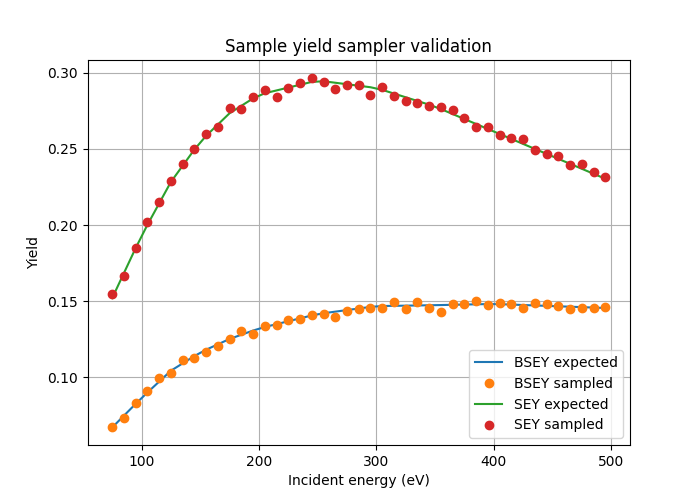

,E_eV,BSEY_input_raw,SEY_input_raw,BSEY_expected,SEY_expected,BSEY_sampled,SEY_sampled
0,75,0.067089,0.151995,0.067089,0.151995,0.06714,0.15480
1,85,0.074843,0.168417,0.074843,0.168417,0.07326,0.16642
2,95,0.082597,0.184839,0.082597,0.184839,0.08314,0.18482
3,105,0.090048,0.200090,0.090048,0.200090,0.09082,0.20166
4,115,0.097194,0.214171,0.097194,0.214171,0.09926,0.21536


In [15]:
Etest = np.arange(75, 501, 10)

df_yield_sample = sweep_yield_sampling(
    yield_models,
    surface_name="grid",
    Etest=Etest,
    N=50_000,
    seed=1,
)

plot_yield_sampling_sweep(
    df_yield_sample,
    title="Sample yield sampler validation",
)

df_yield_sample.head()

In [6]:
def inspect_raw_yields(yield_models):
    rows = []

    surfaces = ["sample", "grid", "collector"]
    energies = [1, 2, 5, 10, 20, 50, 100, 200, 500]

    for fam in surfaces:
        sey_mdl = yield_models[fam]["SEY"]
        bsey_mdl = yield_models[fam]["BSEY"]

        for E in energies:
            sey_base = rfa.interp_yield_model(sey_mdl, E)
            bsey_base = rfa.interp_yield_model(bsey_mdl, E)

            rows.append({
                "family": fam,
                "Einc_eV": E,
                "SEY_base": sey_base,
                "BSEY_base": bsey_base,
                "total_base": sey_base + bsey_base,
            })

    return pd.DataFrame(rows)

df_raw_yields = inspect_raw_yields(yield_models)
display(df_raw_yields)

,family,Einc_eV,SEY_base,BSEY_base,total_base
0,sample,1,0.590589,0.081417,0.672005
1,sample,2,0.590589,0.081417,0.672005
2,sample,5,0.590589,0.081417,0.672005
3,sample,10,0.590589,0.081417,0.672005
4,sample,20,0.590589,0.081417,0.672005
5,sample,50,0.590589,0.081417,0.672005
6,sample,100,0.707605,0.094127,0.801732
7,sample,200,1.007898,0.177458,1.185356
8,sample,500,1.305557,0.417175,1.722732
9,grid,1,0.151995,0.067089,0.219084


In [16]:
def diagnose_sample_surface_event(
    surface_name="g1_shell",
    N=50000,
    grid_SEY_mult=1.0,
    collector_BSE_mult=1.0,
):
    rows = []

    energies = [1, 2, 5, 10, 20, 50, 100, 200, 500]
    cos_values = [1.0, 0.5, 0.2, 0.1, 0.05]

    for Einc in energies:
        for cos_theta in cos_values:
            rng = np.random.default_rng(123)

            nb = 0
            ns = 0

            for _ in range(N):
                did_bse, Nse = rfa.sample_surface_event(
                    yield_models=yield_models,
                    surface_name=surface_name,
                    Einc=Einc,
                    cos_theta=cos_theta,
                    rng=rng,
                    grid_SEY_mult=grid_SEY_mult,
                    collector_BSE_mult=collector_BSE_mult,
                )

                nb += int(did_bse)
                ns += int(Nse)

            rows.append({
                "surface": surface_name,
                "Einc_eV": Einc,
                "cos_theta": cos_theta,
                "BSE_per_hit": nb / N,
                "SE_per_hit": ns / N,
                "total_children_per_hit": (nb + ns) / N,
            })

    return pd.DataFrame(rows)

df_grid_sampler = diagnose_sample_surface_event("g1_shell")
display(df_grid_sampler)

,surface,Einc_eV,cos_theta,BSE_per_hit,SE_per_hit,total_children_per_hit
0,g1_shell,1,1.00,0.00000,0.14898,0.14898
1,g1_shell,1,0.50,0.00000,0.30184,0.30184
2,g1_shell,1,0.20,0.00000,0.75792,0.75792
3,g1_shell,1,0.10,0.00000,1.52678,1.52678
4,g1_shell,1,0.05,0.00000,3.05318,3.05318
5,g1_shell,2,1.00,0.00000,0.14898,0.14898
6,g1_shell,2,0.50,0.00000,0.30184,0.30184
7,g1_shell,2,0.20,0.00000,0.75792,0.75792
8,g1_shell,2,0.10,0.00000,1.52678,1.52678
9,g1_shell,2,0.05,0.00000,3.05318,3.05318


In [17]:
df_grid_normal = diagnose_sample_surface_event(
    surface_name="g1_shell",
    N=50000,
    grid_SEY_mult=1.0,
    collector_BSE_mult=1.0,
)

display(df_grid_normal[df_grid_normal["cos_theta"] == 1.0])

,surface,Einc_eV,cos_theta,BSE_per_hit,SE_per_hit,total_children_per_hit
0,g1_shell,1,1.0,0.00000,0.14898,0.14898
5,g1_shell,2,1.0,0.00000,0.14898,0.14898
10,g1_shell,5,1.0,0.00000,0.14898,0.14898
15,g1_shell,10,1.0,0.00000,0.14898,0.14898
20,g1_shell,20,1.0,0.00000,0.14898,0.14898
25,g1_shell,50,1.0,0.00000,0.14898,0.14898
30,g1_shell,100,1.0,0.08564,0.19348,0.27912
35,g1_shell,200,1.0,0.13158,0.28898,0.42056
40,g1_shell,500,1.0,0.14508,0.23204,0.37712


In [6]:
fam = rfa.surface_family('g1_shell')
Einc_eV = 500

sey_base = rfa.interp_yield_model(
    yield_models[fam]["SEY"],
    Einc_eV,
)

bsey_base = rfa.interp_yield_model(
    yield_models[fam]["BSEY"],
    Einc_eV,
)

vhat = rfa.unit(v_in)
cos_raw = -float(np.dot(vhat, n_out))
cos_used = max(cos_raw, 0.05)

if fam == "grid":
    expected_sey = sey_base / cos_used * (1.0 if grid_SEY_mult is None else grid_SEY_mult)
else:
    expected_sey = sey_base / cos_used

expected_bsey = bsey_base / cos_used

NameError: name 'v_in' is not defined

## Energy distribution sampler diagnostic

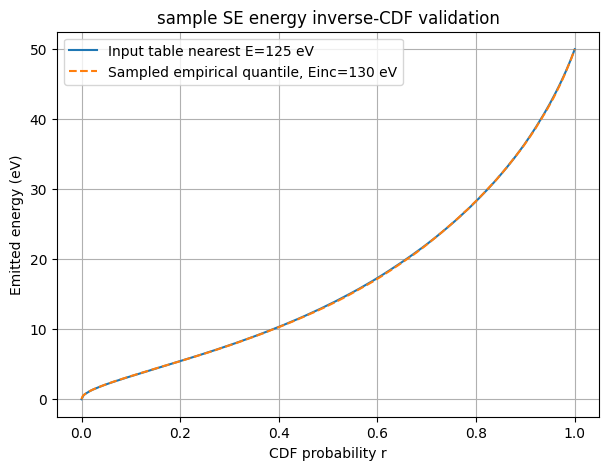

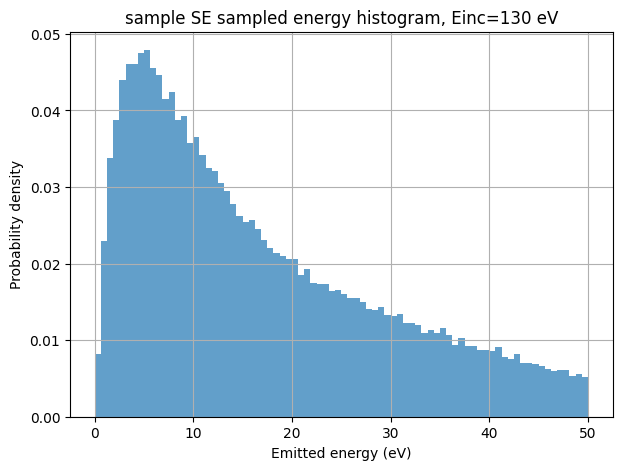

Sample summary:
count    100000.000000
mean         16.834817
std          12.537205
min           0.010000
25%           6.525041
50%          13.375074
75%          25.029897
max          49.997057
dtype: float64


In [11]:
samples_E_sample_SE = plot_energy_inverse_cdf_validation(
    energy_models,
    surface_name="sample",
    kind="SE",
    Einc=130,
    N=100_000,
    seed=1,
)

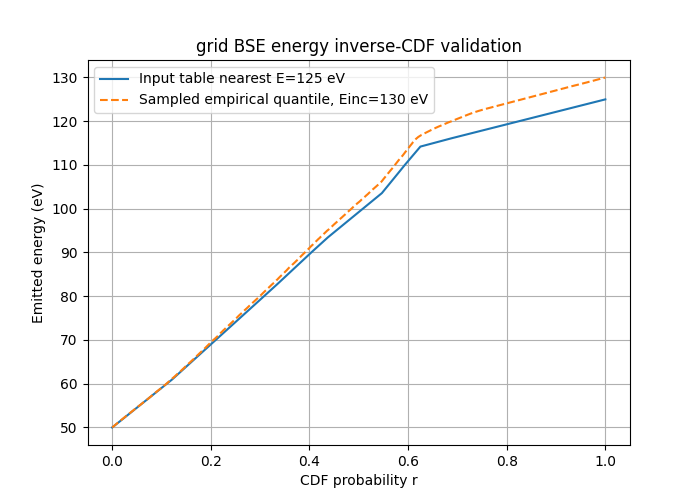

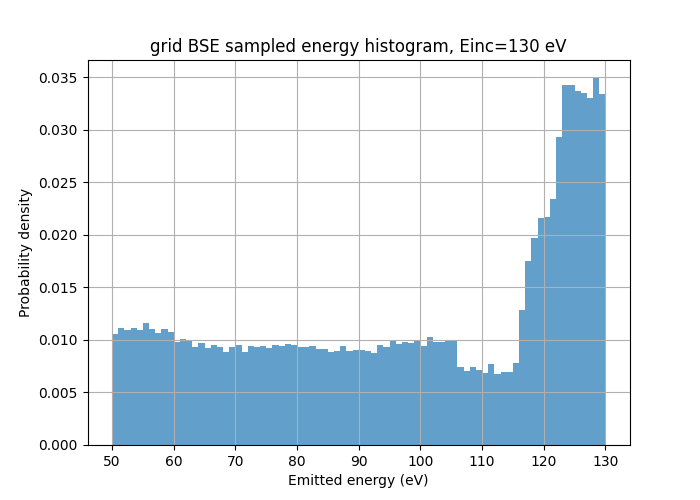

Sample summary:
count    100000.000000
mean         97.699202
std          25.623018
min          50.000576
25%          74.821623
50%         101.494010
75%         122.590920
max         129.999512
dtype: float64


In [18]:
samples_E_sample_BSE = plot_energy_inverse_cdf_validation(
    energy_models,
    surface_name="grid",
    kind="BSE",
    Einc=130,
    N=100_000,
    seed=2,
)

In [6]:
def plot_raw_energy_sampler_table(energy_models, surface_name, kind, Einc):
    fam = surface_family(surface_name)
    kind = kind.upper()

    model = energy_models[fam][kind]
    Egrid = np.asarray(model["E"], dtype=float)

    if Einc <= Egrid[0]:
        idxs = [0]
    elif Einc >= Egrid[-1]:
        idxs = [len(Egrid) - 1]
    else:
        ilo = np.where(Egrid <= Einc)[0][-1]
        ihi = np.where(Egrid >= Einc)[0][0]
        idxs = sorted(set([ilo, ihi]))

    fig, ax = plt.subplots(figsize=(7, 5))

    for idx in idxs:
        tab = model["tables"][idx]
        ax.plot(tab["r"], tab["Eout"], "o-", markersize=3, label=f"table E={Egrid[idx]:.0f} eV")

    ax.set_xlabel("CDF probability r")
    ax.set_ylabel("Emitted energy (eV)")
    ax.set_title(f"Raw inverse-CDF table: {surface_name} {kind}, Einc={Einc:.0f} eV")
    ax.grid(True)
    ax.legend()
    plt.show()

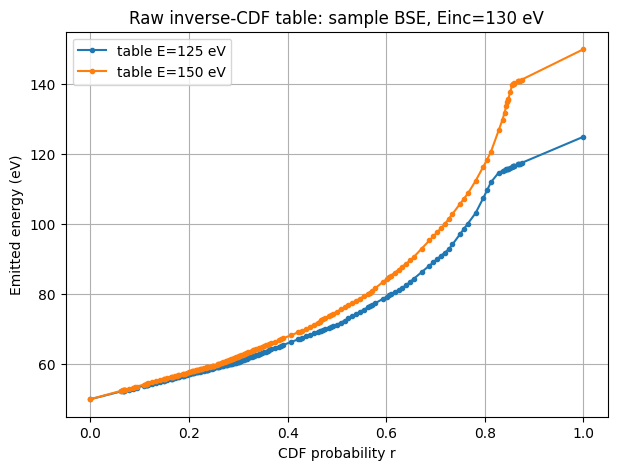

In [7]:
plot_raw_energy_sampler_table(
    energy_models,
    surface_name="sample",
    kind="BSE",
    Einc=130,
)

In [8]:
def sample_energy_from_table_linear(model: dict, Einc: float, rng) -> float:
    """
    Same logic as sample_energy_from_table, but using linear interpolation
    instead of PCHIP.
    """
    Egrid = np.asarray(model["E"], dtype=float)
    tables = model["tables"]

    Einc = float(Einc)
    u = rng.random()

    def eval_table(tab, u):
        r = np.asarray(tab["r"], dtype=float)
        Eout = np.asarray(tab["Eout"], dtype=float)
        u_clip = np.clip(u, r[0], r[-1])
        return float(np.interp(u_clip, r, Eout))

    if Einc <= Egrid[0]:
        return eval_table(tables[0], u)

    if Einc >= Egrid[-1]:
        return eval_table(tables[-1], u)

    ilo = np.where(Egrid <= Einc)[0][-1]
    ihi = np.where(Egrid >= Einc)[0][0]

    if ilo == ihi:
        return eval_table(tables[ilo], u)

    Elo = Egrid[ilo]
    Ehi = Egrid[ihi]
    w = (Einc - Elo) / (Ehi - Elo)

    E_lo = eval_table(tables[ilo], u)
    E_hi = eval_table(tables[ihi], u)

    return (1.0 - w) * E_lo + w * E_hi


def sample_surface_energy_linear(
    energy_models,
    surface_name,
    kind,
    Einc,
    rng,
):
    fam = surface_family(surface_name)
    kind = kind.upper()

    mdl = energy_models[fam][kind]
    Einc = max(float(Einc), 0.01)

    Eraw = sample_energy_from_table_linear(mdl, Einc, rng)

    if kind == "SE":
        Elo = 0.01
        Ehi = min(50.0, Einc)
    elif kind == "BSE":
        if Einc <= 50.0:
            return max(0.01, min(Einc, Eraw))
        Elo = 50.0
        Ehi = Einc
    else:
        raise ValueError(f"Unknown emission kind: {kind}")

    return min(max(Eraw, Elo), Ehi)

In [9]:
def compare_pchip_vs_linear_energy_sampling(
    energy_models,
    surface_name,
    kind,
    Einc,
    N=100_000,
    seed=1,
):
    rng1 = np.random.default_rng(seed)
    rng2 = np.random.default_rng(seed)

    samples_pchip = np.array([
        sample_surface_energy(
            energy_models,
            surface_name,
            kind,
            Einc,
            rng1,
        )
        for _ in range(int(N))
    ])

    samples_linear = np.array([
        sample_surface_energy_linear(
            energy_models,
            surface_name,
            kind,
            Einc,
            rng2,
        )
        for _ in range(int(N))
    ])

    fig, ax = plt.subplots(figsize=(7, 5))

    bins = np.linspace(
        min(samples_pchip.min(), samples_linear.min()),
        max(samples_pchip.max(), samples_linear.max()),
        90,
    )

    ax.hist(samples_pchip, bins=bins, density=True, alpha=0.5, label="PCHIP")
    ax.hist(samples_linear, bins=bins, density=True, alpha=0.5, label="Linear")

    ax.set_xlabel("Emitted energy (eV)")
    ax.set_ylabel("Probability density")
    ax.set_title(f"{surface_name} {kind} energy: PCHIP vs linear, Einc={Einc:.0f} eV")
    ax.grid(True)
    ax.legend()
    plt.show()

    print("PCHIP summary:")
    print(pd.Series(samples_pchip).describe())

    print("\nLinear summary:")
    print(pd.Series(samples_linear).describe())

    return samples_pchip, samples_linear

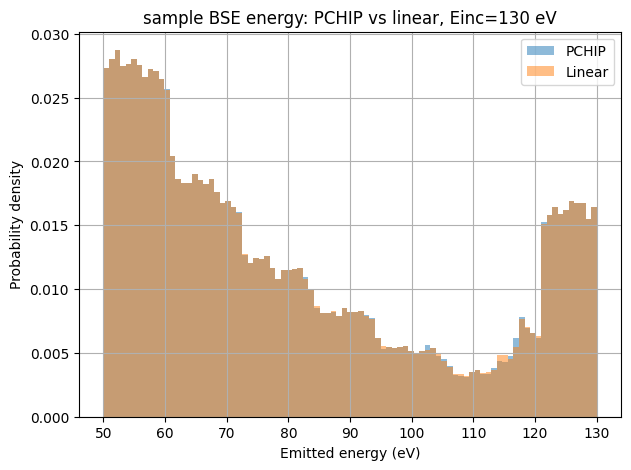

PCHIP summary:
count    100000.000000
mean         80.641292
std          25.405697
min          50.000228
25%          59.063327
50%          72.111108
75%          99.109238
max         129.998990
dtype: float64

Linear summary:
count    100000.000000
mean         80.641491
std          25.404370
min          50.000228
25%          59.063327
50%          72.118223
75%          99.109238
max         129.998990
dtype: float64


In [10]:
samples_pchip, samples_linear = compare_pchip_vs_linear_energy_sampling(
    energy_models,
    surface_name="sample",
    kind="BSE",
    Einc=130,
    N=100_000,
    seed=2,
)

In [11]:
def plot_implied_pdf_from_inverse_cdf(energy_models, surface_name, kind, Einc):
    fam = surface_family(surface_name)
    kind = kind.upper()

    model = energy_models[fam][kind]
    Egrid = np.asarray(model["E"], dtype=float)

    if Einc <= Egrid[0]:
        idxs = [0]
    elif Einc >= Egrid[-1]:
        idxs = [len(Egrid) - 1]
    else:
        ilo = np.where(Egrid <= Einc)[0][-1]
        ihi = np.where(Egrid >= Einc)[0][0]
        idxs = sorted(set([ilo, ihi]))

    fig, ax = plt.subplots(figsize=(7, 5))

    for idx in idxs:
        tab = model["tables"][idx]
        r = np.asarray(tab["r"], dtype=float)
        Eout = np.asarray(tab["Eout"], dtype=float)

        # Use finite differences.
        dE = np.diff(Eout)
        dr = np.diff(r)

        good = dE > 0
        E_mid = 0.5 * (Eout[:-1] + Eout[1:])
        pdf = np.full_like(E_mid, np.nan, dtype=float)
        pdf[good] = dr[good] / dE[good]

        ax.plot(E_mid, pdf, "-", label=f"input table E={Egrid[idx]:.0f} eV")

    ax.set_xlabel("Emitted energy (eV)")
    ax.set_ylabel("Approx. implied PDF")
    ax.set_title(f"Implied PDF from inverse-CDF: {surface_name} {kind}, Einc={Einc:.0f} eV")
    ax.grid(True)
    ax.legend()
    plt.show()

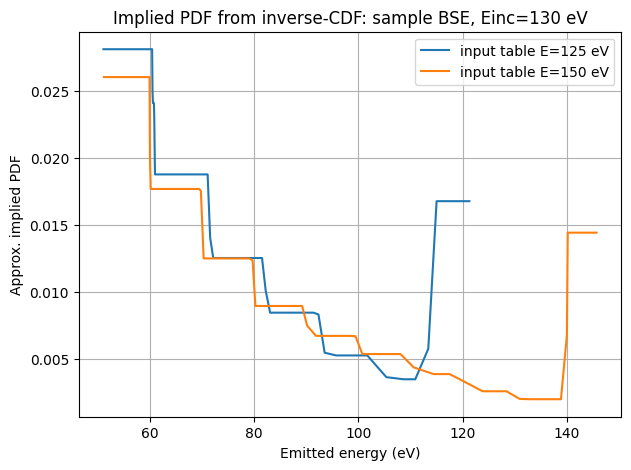

In [12]:
plot_implied_pdf_from_inverse_cdf(
    energy_models,
    surface_name="sample",
    kind="BSE",
    Einc=130,
)

## Theta distribution sampler diagnostic

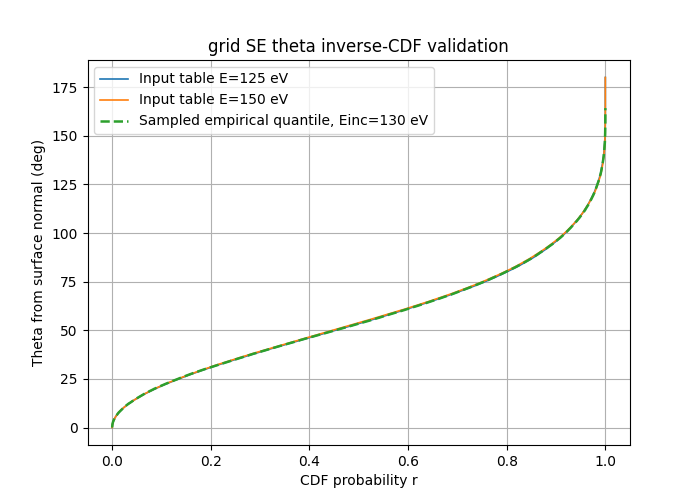

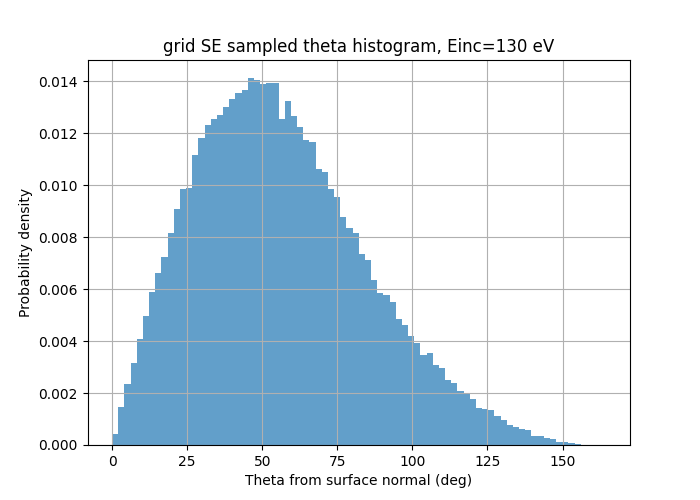

Sample summary:
count    100000.000000
mean         56.431499
std          28.342504
min           0.002648
25%          35.040622
50%          53.418786
75%          74.574836
max         164.268253
dtype: float64


In [11]:
samples_theta_sample_BSE = plot_theta_inverse_cdf_validation(
    theta_models,
    surface_name="grid",
    kind="SE",
    Einc=130,
    N=100_000,
    seed=1,
)

## Overlay SE and BSE energy histograms

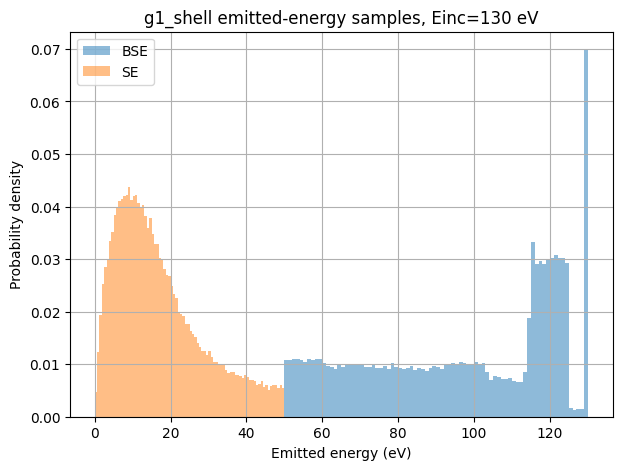

BSE energy:
count    100000.000000
mean         96.728130
std          24.802297
min          50.000069
25%          74.657839
50%         100.690999
75%         119.207874
max         130.000000
dtype: float64

SE energy:
count    100000.000000
mean         17.180461
std          11.613091
min           0.010000
25%           8.261577
50%          14.428042
75%          23.522837
max          49.992082
dtype: float64


In [16]:
E_bse_grid, E_se_grid = plot_se_bse_energy_histograms(
    energy_models,
    surface_name="g1_shell",
    Einc=130,
    N=100_000,
    seed=1,
)